# EEG validation figures

Validation-only comparisons of the fixed baselines and NAS-selected architectures. Locked test results are not used.

In [178]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

dataset_labels = {'bnci2014_001': 'BNCI', 'lee2019_mi': 'Lee', 'physionet_mi': 'PhysioNet'}
model_labels = {
    'compact_eegnet': 'Compact', 'deep_separable': 'Deep', 'wide_eegnet': 'Wide',
    'shallow_temporal': 'Shallow', 'dilated_temporal': 'Dilated',
}
model_order = list(model_labels)
source_colors = {'bnci2014_001': '#2563eb', 'lee2019_mi': '#059669', 'physionet_mi': '#dc2626'}
DATA_ROOT = Path('../data') if Path('../data').exists() else Path('data')

## Fixed baselines vs. NAS-selected architectures

In [179]:
# DATA_ROOT = Path('../data') if Path('../data').exists() else Path('data')
# baseline_calibration_files = sorted(DATA_ROOT.glob('seed-*/benchmarking/calibration/*/calibration_results.jsonl'))
# baseline_files = baseline_calibration_files or sorted(DATA_ROOT.glob('seed-0/benchmarking/*/*/baseline_results.jsonl'))
# calibration_files = sorted(DATA_ROOT.glob('seed-*/eeg-parzen/calibration/*/calibration_results.jsonl'))
# baseline_rows = [
#     {
#         'seed': entry['seed'], 'dataset': entry['dataset'], 'model': entry['baseline'],
#         'validation': entry['validation']['balanced_accuracy'],
#     }
#     for path in baseline_files
#     for entry in (json.loads(line) for line in path.open() if line.strip())
#     if not baseline_calibration_files or entry['epoch'] == 40
# ]
# nas_rows = [
#     {
#         'seed': entry['seed'], 'source': entry['source_dataset'],
#         'dataset': entry['target_dataset'], 'validation': entry['validation']['balanced_accuracy'],
#     }
#     for path in calibration_files
#     for entry in (json.loads(line) for line in path.open() if line.strip())
#     if entry['epoch'] == 40
# ]
# baselines = pd.DataFrame(baseline_rows)
# nas_results = pd.DataFrame(nas_rows)
# dataset_labels = {'bnci2014_001': 'BNCI', 'lee2019_mi': 'Lee', 'physionet_mi': 'PhysioNet'}
# model_labels = {
#     'compact_eegnet': 'Compact', 'deep_separable': 'Deep', 'wide_eegnet': 'Wide',
#     'shallow_temporal': 'Shallow', 'dilated_temporal': 'Dilated',
# }
# model_order = list(model_labels)
# source_colors = {'bnci2014_001': '#2563eb', 'lee2019_mi': '#059669', 'physionet_mi': '#dc2626'}
# for seed in sorted(nas_results['seed'].unique()):
#     fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, constrained_layout=True)
#     fig.suptitle(f'Seed {seed}: matched validation split', fontsize=14)
#     for axis, dataset in zip(axes, dataset_labels, strict=True):
#         baseline = baselines[(baselines['seed'] == seed) & (baselines['dataset'] == dataset)]
#         nas = nas_results[(nas_results['seed'] == seed) & (nas_results['dataset'] == dataset)].sort_values('source')
#         x = list(range(len(model_order)))
#         for position, name in enumerate(model_order):
#             value = baseline.loc[baseline['model'] == name, 'validation'].iloc[0]
#             axis.scatter(position, value, s=55, color='#64748b', zorder=3, label='Fixed baseline' if position == 0 else None)
#             axis.annotate(f'{value:.3f}', (position, value), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=8)
#         nas_groups = [('All NAS', nas, '#7c3aed')] + [
#             (f'From {dataset_labels[source]}', nas[nas['source'] == source], color)
#             for source, color in source_colors.items()
#         ]
#         nas_positions = list(range(len(model_order), len(model_order) + len(nas_groups)))
#         for position, (label, values, color) in zip(nas_positions, nas_groups, strict=True):
#             if len(values) > 1:
#                 box = axis.boxplot(
#                     values['validation'], positions=[position], widths=0.55, patch_artist=True,
#                     boxprops={'facecolor': color, 'edgecolor': color, 'alpha': 0.2},
#                     medianprops={'color': color, 'linewidth': 2},
#                     whiskerprops={'color': color}, capprops={'color': color},
#                 )
#                 box['boxes'][0].set_label('NAS-selected architectures')
#             offsets = [(index - (len(values) - 1) / 2) * 0.08 for index in range(len(values))]
#             axis.scatter([position + offset for offset in offsets], values['validation'], color=color, s=40, zorder=3)
#         delta = nas['validation'].median() - baseline['validation'].max()
#         axis.set_title(f"{dataset_labels[dataset]}  |  NAS median − best baseline: {delta:+.1%}")
#         axis.set_xticks(
#             [*x, *nas_positions],
#             [*[model_labels[name] for name in model_order], *[group[0] for group in nas_groups]],
#             rotation=35, ha='right',
#         )
#         axis.set_ylim(0.5, 0.9)
#         axis.grid(axis='y', alpha=0.25)
#     axes[0].set_ylabel('Validation balanced accuracy')
#     axes[0].legend(loc='lower left', fontsize=8)
#     plt.show()

## Locked-test comparison

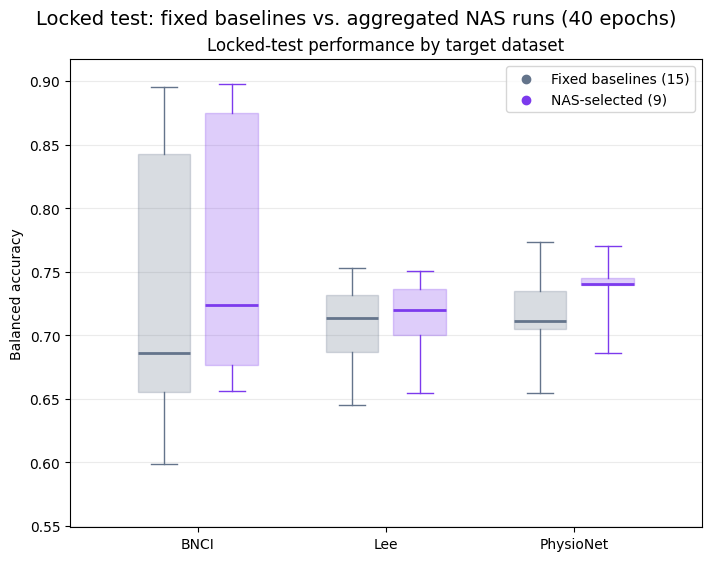

Mean matched NAS improvement: 3.21%
BNCI: 3.97%
Lee: 2.78%
PhysioNet: 2.88%


In [180]:
SHOW_DISTRIBUTION_POINTS = False

baseline_test_files = sorted(DATA_ROOT.glob('seed-*/benchmarking/final-testing/*/epochs-40/test_results.jsonl'))
nas_test_files = sorted(DATA_ROOT.glob('seed-*/eeg-parzen/final-testing/*/epochs-40/test_results.jsonl'))
if len(baseline_test_files) != 3 or len(nas_test_files) != 3:
    raise RuntimeError('Expected three baseline and three NAS final-test files')
baseline_test = pd.DataFrame(
    {
        'seed': entry['seed'], 'dataset': entry['dataset'], 'model': entry['baseline'],
        'value': entry['test']['balanced_accuracy'],
    }
    for path in baseline_test_files
    for entry in (json.loads(line) for line in path.open() if line.strip())
)
nas_test = pd.DataFrame(
    {
        'seed': entry['seed'], 'dataset': entry['target_dataset'], 'source': entry['source_dataset'],
        'value': entry['test']['balanced_accuracy'],
    }
    for path in nas_test_files
    for entry in (json.loads(line) for line in path.open() if line.strip())
)
raw_minimum = min(baseline_test['value'].min(), nas_test['value'].min())
raw_maximum = max(baseline_test['value'].max(), nas_test['value'].max())
fig, distribution_axis = plt.subplots(figsize=(7, 5.5), constrained_layout=True)
group_centers = list(range(len(dataset_labels)))
for center, dataset in zip(group_centers, dataset_labels, strict=True):
    groups = [
        (baseline_test.loc[baseline_test['dataset'] == dataset, 'value'], center - 0.18, '#64748b'),
        (nas_test.loc[nas_test['dataset'] == dataset, 'value'], center + 0.18, '#7c3aed'),
    ]
    for values, position, color in groups:
        distribution_axis.boxplot(
            values, positions=[position], widths=0.28, patch_artist=True, whis=(0, 100),
            boxprops={'facecolor': color, 'edgecolor': color, 'alpha': 0.25},
            medianprops={'color': color, 'linewidth': 2},
            whiskerprops={'color': color}, capprops={'color': color},
        )
        if SHOW_DISTRIBUTION_POINTS:
            offsets = [(index - (len(values) - 1) / 2) * 0.012 for index in range(len(values))]
            distribution_axis.scatter([position + offset for offset in offsets], values, color=color, s=25, alpha=0.8, zorder=3)
distribution_axis.scatter([], [], color='#64748b', label='Fixed baselines (15)')
distribution_axis.scatter([], [], color='#7c3aed', label='NAS-selected (9)')
distribution_axis.set(
    title='Locked-test performance by target dataset',
    ylabel='Balanced accuracy',
    xticks=group_centers,
    xticklabels=[dataset_labels[dataset] for dataset in dataset_labels],
    ylim=(raw_minimum - 0.05, min(1.0, raw_maximum + 0.02)),
)
distribution_axis.grid(axis='y', alpha=0.25)
distribution_axis.legend()
matched_rows = []
for dataset in dataset_labels:
    for seed in sorted(nas_test['seed'].unique()):
        matched_rows.append({
            'dataset': dataset, 'seed': seed,
            'Baseline': baseline_test.loc[(baseline_test['dataset'] == dataset) & (baseline_test['seed'] == seed), 'value'].median(),
            'NAS': nas_test.loc[(nas_test['dataset'] == dataset) & (nas_test['seed'] == seed), 'value'].median(),
        })
matched = pd.DataFrame(matched_rows)
matched['improvement_pct'] = 100 * (matched['NAS'] - matched['Baseline']) / matched['Baseline']
dataset_improvement = matched.groupby('dataset')['improvement_pct'].mean()
overall_improvement = matched['improvement_pct'].mean()
fig.suptitle('Locked test: fixed baselines vs. aggregated NAS runs (40 epochs)', fontsize=14)
plt.show()
print(f'Mean matched NAS improvement: {overall_improvement:.2f}%')
for dataset, improvement in dataset_improvement.items():
    print(f'{dataset_labels[dataset]}: {improvement:.2f}%')

### Configurable normalized composite

Metrics are min–max normalized within each matched seed and target dataset. Lower-is-better metrics are inverted, so a larger normalized value always indicates better performance. Uncomment metrics deliberately: correlated metrics receive separate weight in the composite.

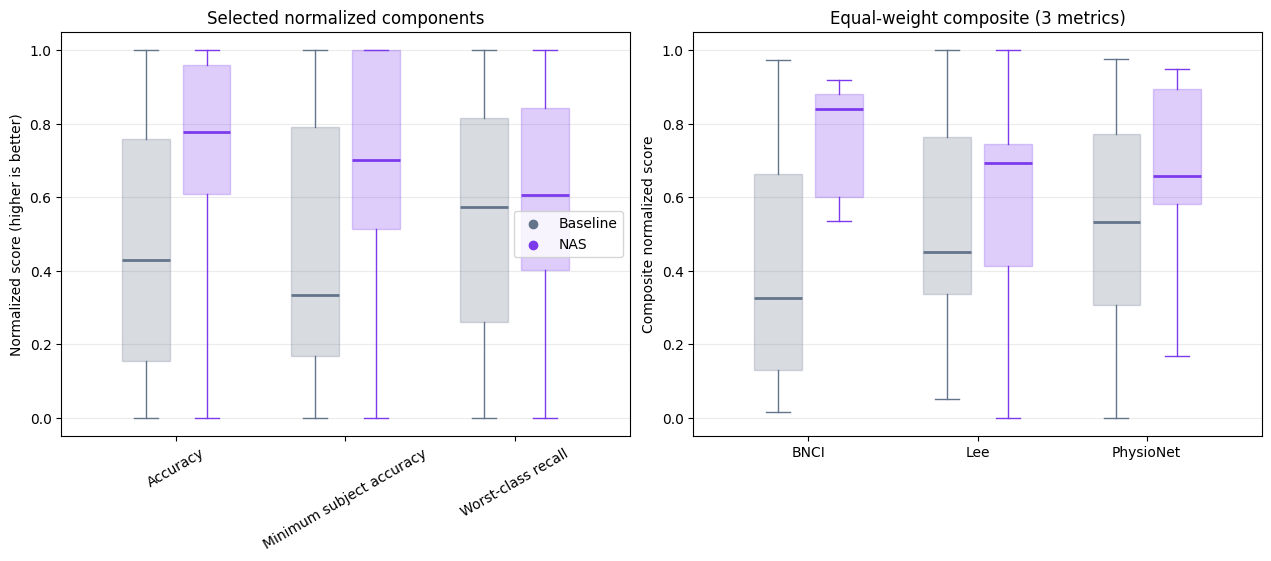

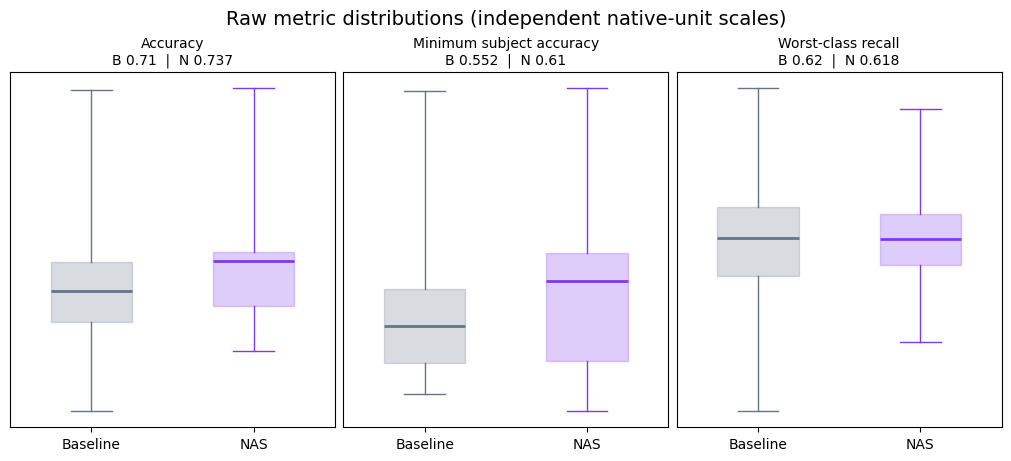

In [181]:
COMPARISON_METRICS = [
    # Predictive quality — choose one
    # 'balanced_accuracy',
    'accuracy',
    # 'macro_f1',
    # 'loss',

    # Subject robustness — choose one
    'subject_min_accuracy',
    # 'subject_median_accuracy',
    # 'subject_accuracy_sd',

    # Class robustness — choose one
    'worst_class_recall',
    # 'left_recall',
    # 'right_recall',
    # 'left_precision',
    # 'right_precision',

    # Inference efficiency — choose one (N/A)
    # 'inference_ms_per_trial',
    # 'inference_trials_per_second',

    # Model efficiency — choose one (N/A)
    # 'parameter_count',
    # 'serialized_state_bytes',

    # Training efficiency — optional; concurrent GPU load affects this
    # 'training_seconds',
]
SHOW_COMPOSITE_POINTS = False

metric_specs = {
    'accuracy': ('Accuracy', True),
    'balanced_accuracy': ('Balanced accuracy', True),
    'macro_f1': ('Macro F1', True),
    'worst_class_recall': ('Worst-class recall', True),
    'left_recall': ('Left recall', True),
    'right_recall': ('Right recall', True),
    'left_precision': ('Left precision', True),
    'right_precision': ('Right precision', True),
    'subject_median_accuracy': ('Median subject accuracy', True),
    'subject_min_accuracy': ('Minimum subject accuracy', True),
    'subject_accuracy_sd': ('Subject accuracy SD', False),
    'loss': ('Cross-entropy loss', False),
    'inference_ms_per_trial': ('Inference time', False),
    'inference_trials_per_second': ('Inference throughput', True),
    'parameter_count': ('Parameters', False),
    'serialized_state_bytes': ('Model size', False),
    'training_seconds': ('Training time', False),
}
unknown_metrics = set(COMPARISON_METRICS) - set(metric_specs)
if not COMPARISON_METRICS or unknown_metrics:
    raise ValueError(f'Select at least one valid metric; unknown: {sorted(unknown_metrics)}')

baseline_training_files = sorted(DATA_ROOT.glob('seed-*/benchmarking/final-training/*/epochs-40/training_results.jsonl'))
nas_training_files = sorted(DATA_ROOT.glob('seed-*/eeg-parzen/final-training/*/epochs-40/training_results.jsonl'))
baseline_training = {
    (entry['seed'], entry['dataset'], entry['baseline']): entry
    for path in baseline_training_files
    for entry in (json.loads(line) for line in path.open() if line.strip())
}
nas_training = {
    (entry['seed'], entry['target_dataset'], entry['source_dataset']): entry
    for path in nas_training_files
    for entry in (json.loads(line) for line in path.open() if line.strip())
}
comparison_rows = []
for family, paths in [('Baseline', baseline_test_files), ('NAS', nas_test_files)]:
    for path in paths:
        for entry in (json.loads(line) for line in path.open() if line.strip()):
            test = entry['test']
            dataset = entry.get('dataset', entry.get('target_dataset'))
            candidate = entry.get('baseline', entry.get('source_dataset'))
            training = (baseline_training if family == 'Baseline' else nas_training)[(entry['seed'], dataset, candidate)]
            subject_scores = pd.Series(test['per_subject_accuracy'].values(), dtype=float)
            comparison_rows.append({
                'family': family, 'seed': entry['seed'], 'dataset': dataset, 'candidate': candidate,
                **{name: test[name] for name in [
                    'loss', 'accuracy', 'balanced_accuracy', 'macro_f1',
                    'left_recall', 'right_recall', 'left_precision', 'right_precision',
                    'inference_ms_per_trial', 'inference_trials_per_second', 'serialized_state_bytes',
                ]},
                'worst_class_recall': min(test['left_recall'], test['right_recall']),
                'subject_median_accuracy': subject_scores.median(),
                'subject_min_accuracy': subject_scores.min(),
                'subject_accuracy_sd': subject_scores.std(),
                'parameter_count': training['parameter_count'],
                'training_seconds': training['training_seconds'],
            })
comparison = pd.DataFrame(comparison_rows)
normalized_rows = []
for (seed, dataset), group in comparison.groupby(['seed', 'dataset']):
    for metric in COMPARISON_METRICS:
        minimum, maximum = group[metric].min(), group[metric].max()
        span = maximum - minimum
        higher_is_better = metric_specs[metric][1]
        for _, row in group.iterrows():
            score = 0.5 if span == 0 else (row[metric] - minimum) / span
            normalized_rows.append({
                'family': row['family'], 'seed': seed, 'dataset': dataset,
                'candidate': row['candidate'], 'metric': metric,
                'score': score if higher_is_better else 1 - score,
            })
normalized_components = pd.DataFrame(normalized_rows)
composite = (
    normalized_components.groupby(['family', 'seed', 'dataset', 'candidate'], as_index=False)['score'].mean()
)
fig, axes = plt.subplots(1, 2, figsize=(max(12, 2.2 * len(COMPARISON_METRICS) + 6), 5.5), constrained_layout=True)
component_axis, composite_axis = axes
colors = {'Baseline': '#64748b', 'NAS': '#7c3aed'}
for center, metric in enumerate(COMPARISON_METRICS):
    for family, position in [('Baseline', center - 0.18), ('NAS', center + 0.18)]:
        values = normalized_components.loc[(normalized_components['metric'] == metric) & (normalized_components['family'] == family), 'score']
        component_axis.boxplot(
            values, positions=[position], widths=0.28, patch_artist=True, whis=(0, 100),
            boxprops={'facecolor': colors[family], 'edgecolor': colors[family], 'alpha': 0.25},
            medianprops={'color': colors[family], 'linewidth': 2},
            whiskerprops={'color': colors[family]}, capprops={'color': colors[family]},
        )
component_axis.set(
    title='Selected normalized components', ylabel='Normalized score (higher is better)',
    xticks=list(range(len(COMPARISON_METRICS))),
    xticklabels=[metric_specs[metric][0] for metric in COMPARISON_METRICS], ylim=(-0.05, 1.05),
)
component_axis.tick_params(axis='x', rotation=30)
component_axis.grid(axis='y', alpha=0.25)
component_axis.scatter([], [], color=colors['Baseline'], label='Baseline')
component_axis.scatter([], [], color=colors['NAS'], label='NAS')
component_axis.legend()
for center, dataset in enumerate(dataset_labels):
    for family, position in [('Baseline', center - 0.18), ('NAS', center + 0.18)]:
        values = composite.loc[(composite['dataset'] == dataset) & (composite['family'] == family), 'score']
        composite_axis.boxplot(
            values, positions=[position], widths=0.28, patch_artist=True, whis=(0, 100),
            boxprops={'facecolor': colors[family], 'edgecolor': colors[family], 'alpha': 0.25},
            medianprops={'color': colors[family], 'linewidth': 2},
            whiskerprops={'color': colors[family]}, capprops={'color': colors[family]},
        )
        if SHOW_COMPOSITE_POINTS:
            offsets = [(index - (len(values) - 1) / 2) * 0.012 for index in range(len(values))]
            composite_axis.scatter([position + offset for offset in offsets], values, color=colors[family], s=24, alpha=0.8, zorder=3)
composite_axis.set(
    title=f'Equal-weight composite ({len(COMPARISON_METRICS)} metrics)',
    ylabel='Composite normalized score', xticks=list(range(len(dataset_labels))),
    xticklabels=[dataset_labels[dataset] for dataset in dataset_labels], ylim=(-0.05, 1.05),
)
composite_axis.grid(axis='y', alpha=0.25)
plt.show()

raw_fig, raw_axes = plt.subplots(
    1, len(COMPARISON_METRICS),
    figsize=(max(10, 2.5 * len(COMPARISON_METRICS)), 4.5),
    squeeze=False, constrained_layout=True,
)
for raw_axis, metric in zip(raw_axes[0], COMPARISON_METRICS, strict=True):
    medians = {}
    for position, family in enumerate(['Baseline', 'NAS']):
        values = comparison.loc[comparison['family'] == family, metric]
        color = colors[family]
        raw_axis.boxplot(
            values, positions=[position], widths=0.5, patch_artist=True, whis=(0, 100),
            boxprops={'facecolor': color, 'edgecolor': color, 'alpha': 0.25},
            medianprops={'color': color, 'linewidth': 2},
            whiskerprops={'color': color}, capprops={'color': color},
        )
        medians[family] = values.median()
    raw_axis.set(xticks=[0, 1], xticklabels=['Baseline', 'NAS'], yticks=[])
    raw_axis.set_title(
        f"{metric_specs[metric][0]}\nB {medians['Baseline']:.3g}  |  N {medians['NAS']:.3g}",
        fontsize=10,
    )
    raw_axis.grid(axis='y', alpha=0.2)
raw_fig.suptitle('Raw metric distributions (independent native-unit scales)', fontsize=14)
plt.show()

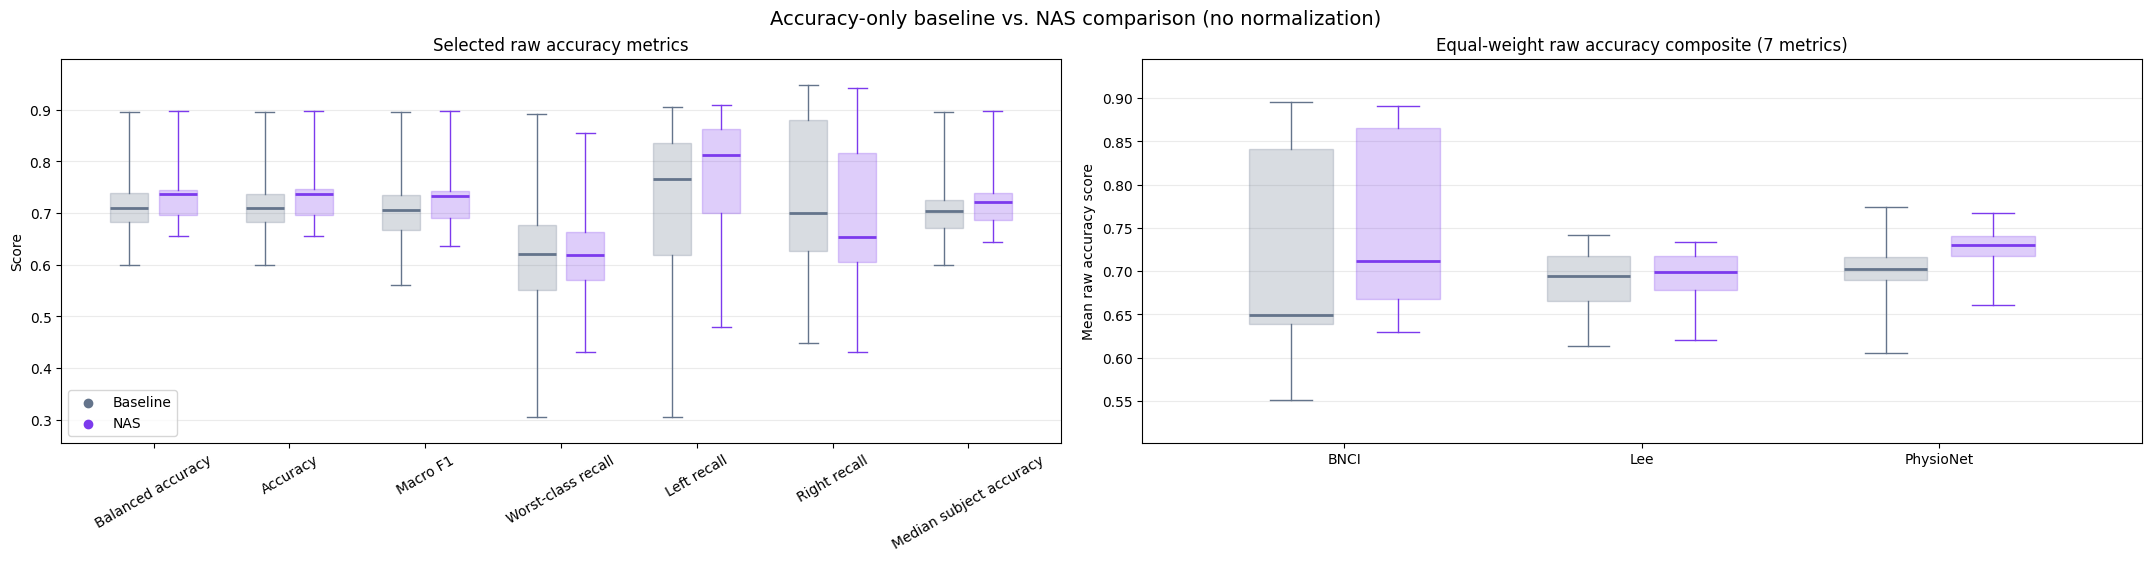

In [182]:
# Accuracy-only comparison (raw 0–1 values; no normalization)
ACCURACY_METRICS = [
    # Overall predictive quality — choose one
    'balanced_accuracy',
    'accuracy',
    'macro_f1',

    # Class robustness — choose one or omit this section
    'worst_class_recall',
    'left_recall', # among all true left trials, how many were predicted as left?
    'right_recall', # among all true right trials, how many were predicted as right?
    # 'left_precision',
    # 'right_precision',

    # Subject robustness — choose one or omit this section
    # 'subject_min_accuracy',
    'subject_median_accuracy',
]

accuracy_metric_labels = {
    'accuracy': 'Accuracy',
    'balanced_accuracy': 'Balanced accuracy',
    'macro_f1': 'Macro F1',
    'worst_class_recall': 'Worst-class recall',
    'left_recall': 'Left recall',
    'right_recall': 'Right recall',
    'left_precision': 'Left precision',
    'right_precision': 'Right precision',
    'subject_median_accuracy': 'Median subject accuracy',
    'subject_min_accuracy': 'Minimum subject accuracy',
}
unknown_accuracy_metrics = set(ACCURACY_METRICS) - set(accuracy_metric_labels)
if not ACCURACY_METRICS or unknown_accuracy_metrics:
    raise ValueError(f'Select at least one valid accuracy metric; unknown: {sorted(unknown_accuracy_metrics)}')

accuracy_long = comparison.melt(
    id_vars=['family', 'seed', 'dataset', 'candidate'],
    value_vars=ACCURACY_METRICS,
    var_name='metric', value_name='score',
)
accuracy_composite = (
    accuracy_long.groupby(['family', 'seed', 'dataset', 'candidate'], as_index=False)['score'].mean()
)
component_ylim = (accuracy_long['score'].min() - 0.05, accuracy_long['score'].max() + 0.05)
composite_ylim = (accuracy_composite['score'].min() - 0.05, accuracy_composite['score'].max() + 0.05)
fig, axes = plt.subplots(
    1, 2, figsize=(max(12, 2.2 * len(ACCURACY_METRICS) + 6), 5.5), constrained_layout=True,
)
component_axis, composite_axis = axes
colors = {'Baseline': '#64748b', 'NAS': '#7c3aed'}
for center, metric in enumerate(ACCURACY_METRICS):
    for family, position in [('Baseline', center - 0.18), ('NAS', center + 0.18)]:
        values = accuracy_long.loc[(accuracy_long['metric'] == metric) & (accuracy_long['family'] == family), 'score']
        component_axis.boxplot(
            values, positions=[position], widths=0.28, patch_artist=True, whis=(0, 100),
            boxprops={'facecolor': colors[family], 'edgecolor': colors[family], 'alpha': 0.25},
            medianprops={'color': colors[family], 'linewidth': 2},
            whiskerprops={'color': colors[family]}, capprops={'color': colors[family]},
        )
component_axis.set(
    title='Selected raw accuracy metrics', ylabel='Score',
    xticks=list(range(len(ACCURACY_METRICS))),
    xticklabels=[accuracy_metric_labels[metric] for metric in ACCURACY_METRICS],
    ylim=component_ylim,
)
component_axis.tick_params(axis='x', rotation=30)
component_axis.grid(axis='y', alpha=0.25)
component_axis.scatter([], [], color=colors['Baseline'], label='Baseline')
component_axis.scatter([], [], color=colors['NAS'], label='NAS')
component_axis.legend()
for center, dataset in enumerate(dataset_labels):
    for family, position in [('Baseline', center - 0.18), ('NAS', center + 0.18)]:
        values = accuracy_composite.loc[(accuracy_composite['dataset'] == dataset) & (accuracy_composite['family'] == family), 'score']
        composite_axis.boxplot(
            values, positions=[position], widths=0.28, patch_artist=True, whis=(0, 100),
            boxprops={'facecolor': colors[family], 'edgecolor': colors[family], 'alpha': 0.25},
            medianprops={'color': colors[family], 'linewidth': 2},
            whiskerprops={'color': colors[family]}, capprops={'color': colors[family]},
        )
composite_axis.set(
    title=f'Equal-weight raw accuracy composite ({len(ACCURACY_METRICS)} metrics)',
    ylabel='Mean raw accuracy score', xticks=list(range(len(dataset_labels))),
    xticklabels=[dataset_labels[dataset] for dataset in dataset_labels], ylim=composite_ylim,
)
composite_axis.grid(axis='y', alpha=0.25)
fig.suptitle('Accuracy-only baseline vs. NAS comparison (no normalization)', fontsize=14)
plt.show()